<a href="https://colab.research.google.com/github/smithve-laf/smith-repository-notebook/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Tori Smith
#####*Intro to Neural Data Analysis*
#####**03/06/2026**

In [ ]:
#step 2
#importing packages
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
#step 3
#uploading data
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'

patch_seq = pd.read_csv(url)
print(patch_seq)

           ISI  Fast_Trough Marker
0    77.337143   -49.899998    Sst
1    17.177895   -44.462498    Sst
2    48.294737   -47.350002    Sst
3     8.980000   -45.656254    Sst
4    30.315385   -50.737499    Sst
..         ...          ...    ...
360  11.052333   -54.743752  Pvalb
361   8.860360   -64.875008  Pvalb
362   9.192897   -51.312504  Pvalb
363  10.544731   -52.281254  Pvalb
364  16.396364   -61.437504  Pvalb

[365 rows x 3 columns]


Text(0, 0.5, 'Number of Observations')

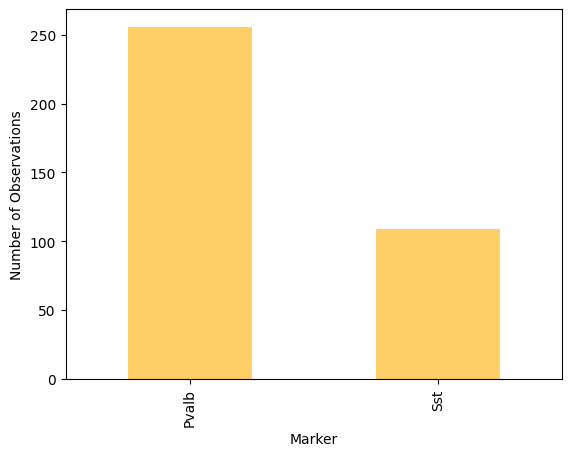

In [ ]:
#step 4
#making a bar graph, displays value counts from marker column.
marker_counts = patch_seq['Marker']. value_counts()
marker_counts.plot(kind = 'bar', colormap = 'managua')

plt.xlabel('Marker')
plt.ylabel('Number of Observations')

Text(0, 0.5, 'Number of Observations')

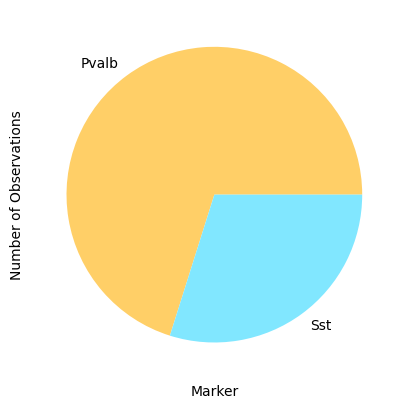

In [ ]:
#step 5
#repeat but with pie chart
marker_counts = patch_seq['Marker']. value_counts()
marker_counts.plot(kind = 'pie', colormap = 'managua')

plt.xlabel('Marker')
plt.ylabel('Number of Observations')

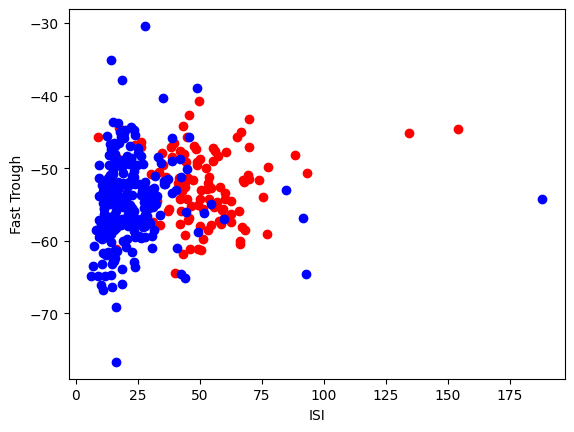

In [ ]:
#step 6
#for loop scatter plot of isi and fast trough data.

patch_length = len(patch_seq)

plt.xlabel('ISI')
plt.ylabel('Fast Trough')

for i in range(patch_length):
  if patch_seq.iloc[i,2] == 'Sst': #[i,2] is all the rows in the 2 column which is marker
    plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'red') #[i,0] ISI [i,1] Fast_Trough
  if patch_seq.iloc[i,2] == 'Pvalb':
    plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'blue')

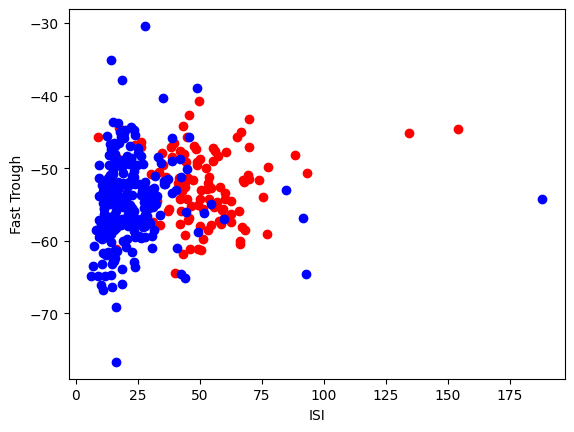

In [ ]:
#step 7
#function for scatterplot
def patchScatter():
  """
  This function will create a scatter plot of ISI vs. Fast Trough for Sst-containing and Pvalb-containing neurons.
  """
  patch_length = len(patch_seq)

  plt.xlabel('ISI')
  plt.ylabel('Fast Trough')

  for i in range(patch_length):
    if patch_seq.iloc[i,2] == 'Sst': #[i,2] is all the rows in the 2 column which is marker
      plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'red') #[i,0] ISI [i,1] Fast_Trough
    if patch_seq.iloc[i,2] == 'Pvalb':
      plt.scatter(patch_seq.iloc[i,0], patch_seq.iloc[i,1], color = 'blue')

patchScatter()

In [ ]:
#step 8
#mean, standard dev, and range of columns.
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


#####The mean value for Sst neurons was -54.54 mV, while the mean for Pvalb neurons was -52.51 mV. This shows that Sst neurons have a more negative undershoot following an action potential.

In [ ]:
#step 10
#this would be the easiest way, and it would apply to the same syntax used in step 8
patch_seq.groupby('Marker')['Fast_Trough'].apply(stats.skewtest)

#or you could do it like this
sst_fast_trough = patch_seq[patch_seq['Marker'] == 'Sst']['Fast_Trough']
pvalb_fast_trough = patch_seq[patch_seq['Marker'] == 'Pvalb']['Fast_Trough']

print(stats.skewtest(sst_fast_trough))
print(stats.skewtest(pvalb_fast_trough))

SkewtestResult(statistic=np.float64(0.00556907494240316), pvalue=np.float64(0.9955565440541793))
SkewtestResult(statistic=np.float64(1.2923680650700955), pvalue=np.float64(0.19622971058812222))


#####Based on these results, for SST neurons, 0.005 is very close to 0, which indicates the distribution is symmetric. The pvalue for SST neurons is much greater than 0.05, which means the skew is not statistically significant. The Fast Trough distribution for SST neurons is not skewed. For PVALB neurons the stat is 1.29 which is further from 0 which suggests some asymmetry. But the pvalue is greater than 0.05 which says the skew is not statistically significant. Both are considered symmetric.

In [ ]:
#step 12
#repeating for ISI column
patch_seq.groupby('Marker')['ISI'].apply(stats.skewtest)

#another way to do it
sst_isi = patch_seq[patch_seq['Marker'] == 'Sst']['ISI']
pvalb_isi = patch_seq[patch_seq['Marker'] == 'Pvalb']['ISI']

print(stats.skewtest(sst_isi))
print(stats.skewtest(pvalb_isi))
#nan nan = not enough observations to compute skew test

SkewtestResult(statistic=np.float64(5.931555169212854), pvalue=np.float64(3.0007869817767663e-09))
SkewtestResult(statistic=np.float64(nan), pvalue=np.float64(nan))


#####The large positive number for SST neurons in the ISI column suggests the distribution is skewed to the right. The pvalue is extremely small which suggests the skew is statistically significant. Because of the results for PVALB ISI, there is not enough data in this column to determine skewness.

In [ ]:
#step 14
#t-test
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

#####Based on this t-test, the pvalue = 0.00167 which means there is a statistically significant difference in the mean undershoot voltage between SST and PVALB neurons. And from earlier we know SST neurons have a more negative undershoot (larger fast trough) than PVALB neurons.

In [ ]:
#step 16
#same method for ISI values
#ISI contains missing values, thats why we got the nan nan result
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()
#this code gets rid of the missing values in the ISI column.

#then run the t-test
stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

#####This pvalue is much much smaller than 0.05. This means that the ISI values significantly differ between SST and PVALB neurons.